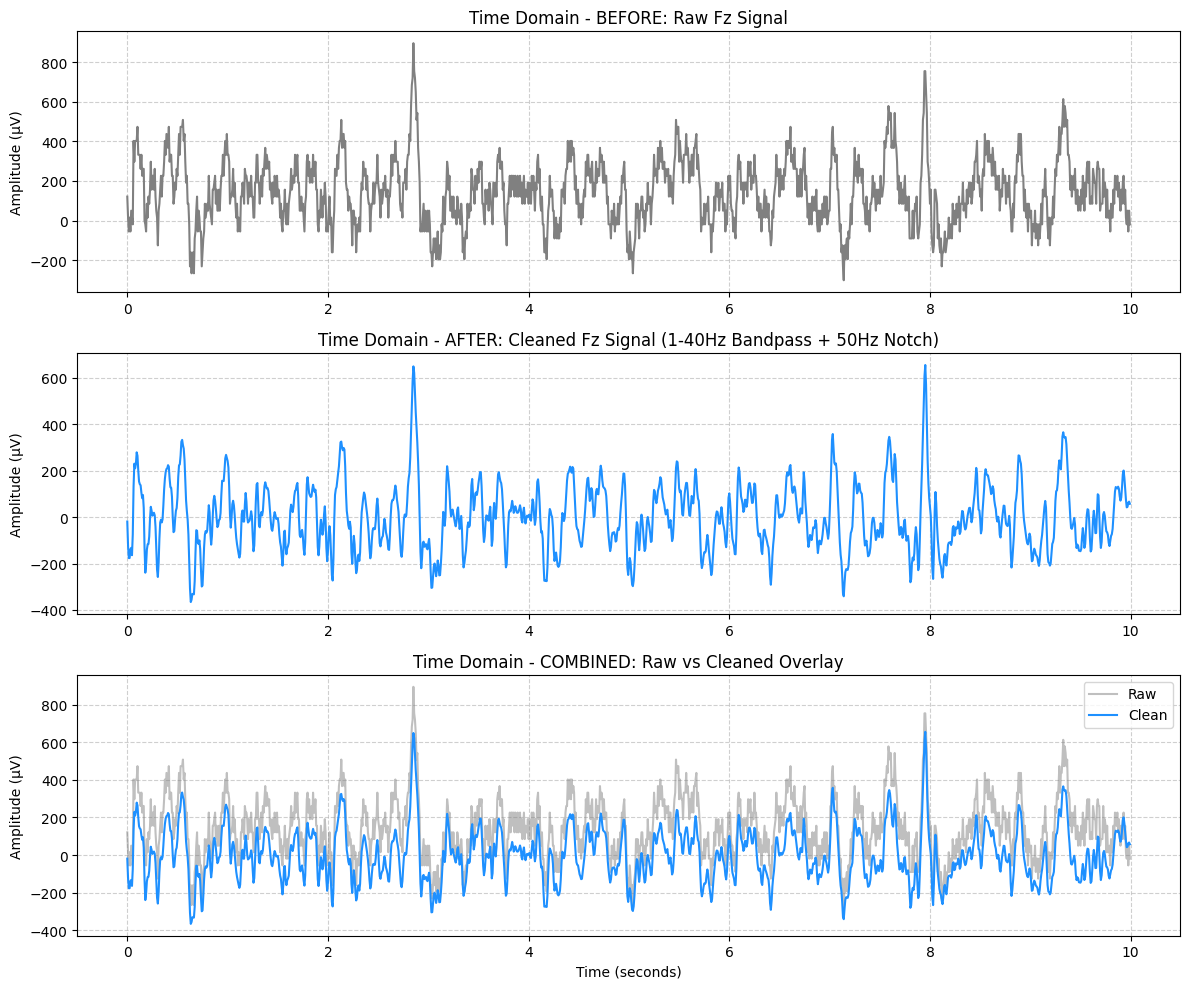

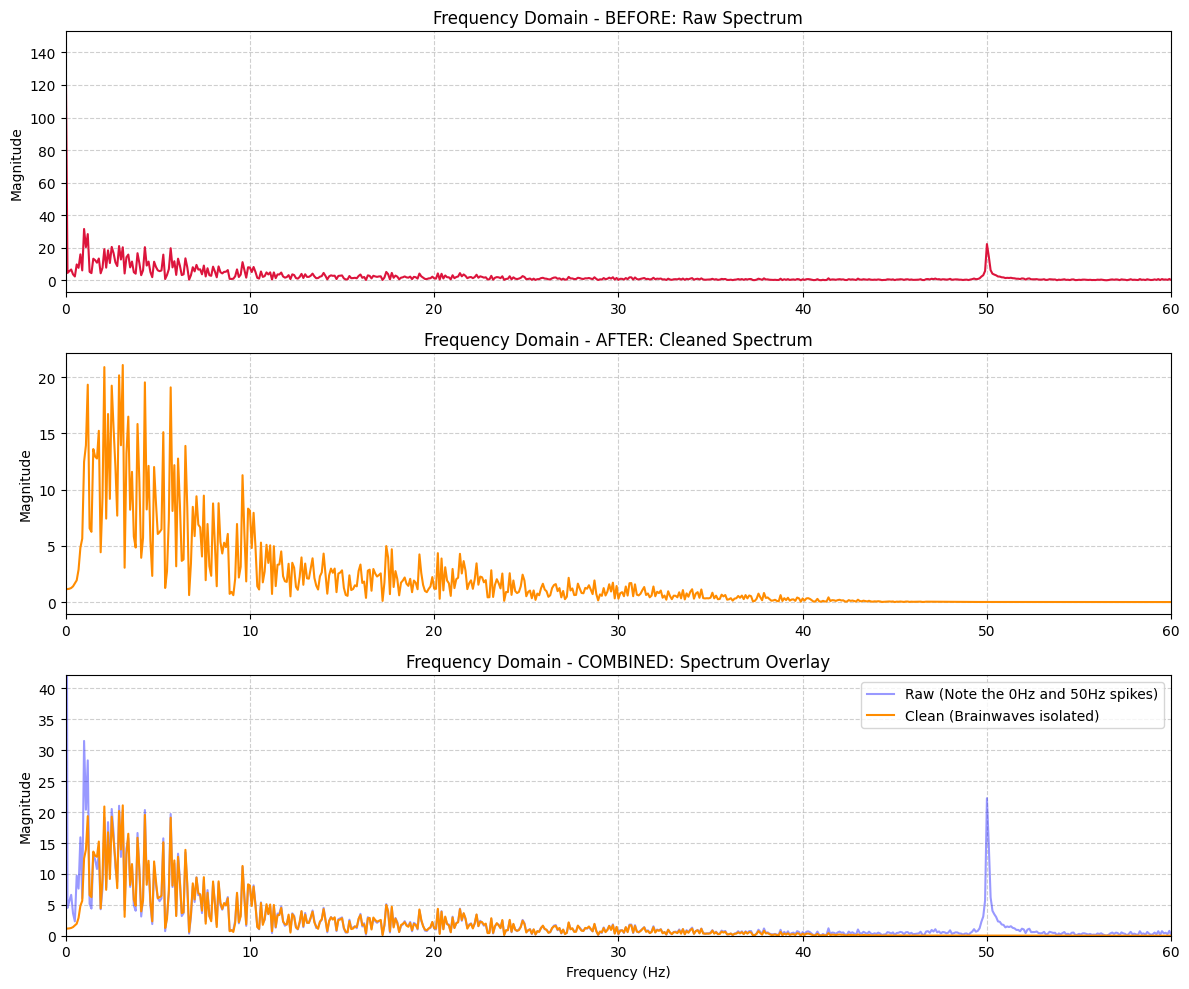

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ==========================================
# 1. LOAD AND PREP DATA
# ==========================================
# Load the dataset
df = pd.read_csv("adhdata.csv")

# Extract 1280 samples (10 seconds) specifically from the Fz channel
fz_samples = df['Fz'].iloc[:1280]

# Time parameters
fs = 128.0       # Sampling frequency in Hz
n = len(fz_samples)
time = np.arange(n) / fs

# ==========================================
# 2. FILTERING (Notch + Bandpass)
# ==========================================
# A. 50 Hz Notch Filter
f0 = 50.0  
Q = 30.0   
b_notch, a_notch = signal.iirnotch(f0, Q, fs)
fz_notch = signal.filtfilt(b_notch, a_notch, fz_samples)

# B. 1-40 Hz Butterworth Bandpass Filter
lowcut = 1.0   
highcut = 40.0 
order = 4      
b_band, a_band = signal.butter(order, [lowcut, highcut], btype='bandpass', fs=fs)
fz_clean = signal.filtfilt(b_band, a_band, fz_notch)

# ==========================================
# 3. COMPUTE FFT (Before and After)
# ==========================================
# FFT for Raw Data
fft_raw = np.abs(np.fft.fft(fz_samples)) / n
# FFT for Clean Data
fft_clean = np.abs(np.fft.fft(fz_clean)) / n

# Frequencies for x-axis
frequencies = np.fft.fftfreq(n, d=1/fs)
half_n = n // 2
pos_freqs = frequencies[:half_n]
pos_raw_mag = fft_raw[:half_n]
pos_clean_mag = fft_clean[:half_n]

# ==========================================
# 4. PLOT 1: TIME DOMAIN (Before, After, Combined)
# ==========================================
plt.figure(figsize=(12, 10))

# Time - Before
plt.subplot(3, 1, 1)
plt.plot(time, fz_samples, color='gray')
plt.title("Time Domain - BEFORE: Raw Fz Signal")
plt.ylabel("Amplitude (µV)")
plt.grid(True, linestyle='--', alpha=0.6)

# Time - After
plt.subplot(3, 1, 2)
plt.plot(time, fz_clean, color='dodgerblue')
plt.title("Time Domain - AFTER: Cleaned Fz Signal (1-40Hz Bandpass + 50Hz Notch)")
plt.ylabel("Amplitude (µV)")
plt.grid(True, linestyle='--', alpha=0.6)

# Time - Combined
plt.subplot(3, 1, 3)
plt.plot(time, fz_samples, color='gray', alpha=0.5, label='Raw')
plt.plot(time, fz_clean, color='dodgerblue', linewidth=1.5, label='Clean')
plt.title("Time Domain - COMBINED: Raw vs Cleaned Overlay")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================
# 5. PLOT 2: FREQUENCY DOMAIN (Before, After, Combined)
# ==========================================

plt.figure(figsize=(12, 10))

# Frequency - Before
plt.subplot(3, 1, 1)
plt.plot(pos_freqs, pos_raw_mag, color='crimson')
plt.title("Frequency Domain - BEFORE: Raw Spectrum")
plt.ylabel("Magnitude")
plt.xlim(0, 60)
plt.grid(True, linestyle='--', alpha=0.6)

# Frequency - After
plt.subplot(3, 1, 2)
plt.plot(pos_freqs, pos_clean_mag, color='darkorange')
plt.title("Frequency Domain - AFTER: Cleaned Spectrum")
plt.ylabel("Magnitude")
plt.xlim(0, 60)
plt.grid(True, linestyle='--', alpha=0.6)

# Frequency - Combined
plt.subplot(3, 1, 3)
plt.plot(pos_freqs, pos_raw_mag, color='blue', alpha=0.4, label='Raw (Note the 0Hz and 50Hz spikes)')
plt.plot(pos_freqs, pos_clean_mag, color='darkorange', linewidth=1.5, label='Clean (Brainwaves isolated)')
plt.title("Frequency Domain - COMBINED: Spectrum Overlay")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 60)
# Optional: Set a y-limit on the combined plot to prevent the 0Hz raw spike from hiding the clean data
plt.ylim(0, max(pos_clean_mag) * 2) 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ==========================================
# 1. LOAD DATA & SETUP
# ==========================================
df = pd.read_csv("adhdata.csv")

# The corrected 19 channels (T3->T7, T4->T8, T5->P7, T6->P8)
channels = [
    'Fz', 'Cz', 'Pz', 'C3', 'T7', 'C4', 'T8', 'Fp1', 'Fp2', 
    'F3', 'F4', 'F7', 'F8', 'P3', 'P4', 'P7', 'P8', 'O1', 'O2'
]

fs = 128.0
num_samples = 1280  # Analyzing the first 10 seconds (1280 samples)
time = np.arange(num_samples) / fs

# ==========================================
# 2. DESIGN FILTERS
# ==========================================
# 50 Hz Notch Filter
b_notch, a_notch = signal.iirnotch(50.0, 30.0, fs)
# 1-40 Hz Butterworth Bandpass Filter (4th Order)
b_band, a_band = signal.butter(4, [1.0, 40.0], btype='bandpass', fs=fs)

# ==========================================
# 3. LOOP THROUGH ALL 19 CHANNELS
# ==========================================
print("Generating plots...")

for ch in channels:
    # --- A. Extract and Filter ---
    raw_signal = df[ch].iloc[:num_samples].values
    
    notched_signal = signal.filtfilt(b_notch, a_notch, raw_signal)
    clean_signal = signal.filtfilt(b_band, a_band, notched_signal)
    
    # --- B. Compute FFT (Before and After) ---
    n = len(raw_signal)
    freqs = np.fft.fftfreq(n, d=1/fs)
    half_n = n // 2
    pos_freqs = freqs[:half_n]
    
    # FFT Before
    fft_raw = np.abs(np.fft.fft(raw_signal)) / n
    pos_fft_raw = fft_raw[:half_n]
    
    # FFT After
    fft_clean = np.abs(np.fft.fft(clean_signal)) / n
    pos_fft_clean = fft_clean[:half_n]
    
    # --- C. Create 2x2 Plot ---
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Channel: {ch} - Signal Processing Analysis", fontsize=18, fontweight='bold')
    
    # [Top Left] Time Domain - BEFORE
    axs[0, 0].plot(time, raw_signal, color='gray')
    axs[0, 0].set_title(f"Time Domain: BEFORE Filter")
    axs[0, 0].set_xlabel("Time (seconds)")
    axs[0, 0].set_ylabel("Amplitude (µV)")
    axs[0, 0].grid(True, linestyle='--', alpha=0.6)
    
    # [Top Right] Time Domain - AFTER
    axs[0, 1].plot(time, clean_signal, color='dodgerblue')
    axs[0, 1].set_title(f"Time Domain: AFTER Filter (1-40Hz Bandpass + 50Hz Notch)")
    axs[0, 1].set_xlabel("Time (seconds)")
    axs[0, 1].set_ylabel("Amplitude (µV)")
    axs[0, 1].grid(True, linestyle='--', alpha=0.6)
    
    # [Bottom Left] Freq Domain - BEFORE
    axs[1, 0].plot(pos_freqs, pos_fft_raw, color='crimson')
    axs[1, 0].set_title(f"Frequency Domain: BEFORE Filter")
    axs[1, 0].set_xlabel("Frequency (Hz)")
    axs[1, 0].set_ylabel("Magnitude")
    axs[1, 0].set_xlim(0, 60)
    axs[1, 0].grid(True, linestyle='--', alpha=0.6)
    
    # [Bottom Right] Freq Domain - AFTER
    axs[1, 1].plot(pos_freqs, pos_fft_clean, color='darkorange')
    axs[1, 1].set_title(f"Frequency Domain: AFTER Filter")
    axs[1, 1].set_xlabel("Frequency (Hz)")
    axs[1, 1].set_ylabel("Magnitude")
    axs[1, 1].set_xlim(0, 60)
    axs[1, 1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # --- D. Save and Close ---
    # Saves as "Fz_analysis.png", "Cz_analysis.png", etc.
    filename = f"{ch}_analysis.png"
    plt.savefig(filename)
    plt.close(fig) # Closes the figure so it doesn't consume all your RAM
    
    print(f"Saved: {filename}")

print("✅ All 19 plots successfully generated and saved to your directory!")

Generating plots...
Saved: Fz_analysis.png
Saved: Cz_analysis.png
Saved: Pz_analysis.png
Saved: C3_analysis.png
Saved: T7_analysis.png
Saved: C4_analysis.png
Saved: T8_analysis.png
Saved: Fp1_analysis.png
Saved: Fp2_analysis.png
Saved: F3_analysis.png
Saved: F4_analysis.png
Saved: F7_analysis.png
Saved: F8_analysis.png
Saved: P3_analysis.png
Saved: P4_analysis.png
Saved: P7_analysis.png
Saved: P8_analysis.png
Saved: O1_analysis.png
Saved: O2_analysis.png
✅ All 19 plots successfully generated and saved to your directory!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import FastICA

# ==========================================
# 1. LOAD DATA & SETUP
# ==========================================
df = pd.read_csv("adhdata.csv")

# 19 Channels (Modified Combinatorial Nomenclature)
channels = [
    'Fz', 'Cz', 'Pz', 'C3', 'T7', 'C4', 'T8', 'Fp1', 'Fp2', 
    'F3', 'F4', 'F7', 'F8', 'P3', 'P4', 'P7', 'P8', 'O1', 'O2'
]

fs = 128.0
num_samples = 1280  # 10 seconds of data
time = np.arange(num_samples) / fs

# Extract exactly 10 seconds for all 19 channels as a matrix
raw_matrix = df[channels].iloc[:num_samples].values

# ==========================================
# 2. FREQUENCY FILTERING (All channels at once)
# ==========================================
# 50 Hz Notch
b_notch, a_notch = signal.iirnotch(50.0, 30.0, fs)
notched_matrix = signal.filtfilt(b_notch, a_notch, raw_matrix, axis=0)

# 1-40 Hz Bandpass
b_band, a_band = signal.butter(4, [1.0, 40.0], btype='bandpass', fs=fs)
filtered_matrix = signal.filtfilt(b_band, a_band, notched_matrix, axis=0)

# ==========================================
# 3. INDEPENDENT COMPONENT ANALYSIS (ICA)
# ==========================================
print("Running ICA to remove ocular artifacts (blinks)...")

# Initialize and fit ICA
ica = FastICA(n_components=19, random_state=42, max_iter=1000)
ica_sources = ica.fit_transform(filtered_matrix)

# Heuristic: Find the component most correlated with the Fp1 channel (Channel Index 7)
fp1_filtered = filtered_matrix[:, 7]
correlations = [np.abs(np.corrcoef(fp1_filtered, ica_sources[:, i])[0, 1]) for i in range(19)]

# Identify the "blink" component and zero it out
blink_component_idx = np.argmax(correlations)
print(f"-> Automatically zeroed out ICA Component {blink_component_idx} (Highly correlated with Fp1 blinks)")
ica_sources[:, blink_component_idx] = 0

# Reconstruct the cleaned EEG matrix without the blink component
ica_clean_matrix = ica.inverse_transform(ica_sources)

# ==========================================
# 4. CHANNEL LOOP: PLOT TIME, PSD, & SPECTROGRAM
# ==========================================
print("Generating final analysis plots for each channel...")

for i, ch in enumerate(channels):
    # Extract the fully cleaned 1D array for this specific channel
    clean_signal = ica_clean_matrix[:, i]
    raw_signal = raw_matrix[:, i]
    
    # Create a nice layout: Top row for Time, Bottom row split for PSD and Spectrogram
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f"Channel: {ch} - Advanced Spectral & ICA Analysis", fontsize=18, fontweight='bold')
    
    # --- Plot 1: Time Domain (Top, spans both columns) ---
    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(time, raw_signal, color='gray', alpha=0.4, label='Raw (Noisy)')
    ax1.plot(time, clean_signal, color='teal', linewidth=1.5, label='Filtered + ICA Cleaned')
    ax1.set_title("Time Domain: Artifact Rejection via FastICA")
    ax1.set_xlabel("Time (seconds)")
    ax1.set_ylabel("Amplitude (µV)")
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # --- Plot 2: Power Spectral Density (Bottom Left) ---
    ax2 = plt.subplot(2, 2, 3)
    freqs_psd, psd = signal.welch(clean_signal, fs, nperseg=256)
    ax2.semilogy(freqs_psd, psd, color='navy', linewidth=1.5)
    ax2.set_title("Welch's Power Spectral Density (PSD)")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("PSD ($V^2$/Hz)")
    ax2.set_xlim(0, 45)  # Cut off just past our 40Hz bandpass
    ax2.grid(True, which='both', linestyle='--', alpha=0.5)
    
    # --- Plot 3: Spectrogram (Bottom Right) ---
    ax3 = plt.subplot(2, 2, 4)
    # Using matplotlib's specgram. We use the cleaned signal.
    Pxx, freqs_spec, bins, im = ax3.specgram(clean_signal, Fs=fs, NFFT=128, noverlap=64, cmap='viridis')
    ax3.set_title("Spectrogram (Time-Frequency)")
    ax3.set_xlabel("Time (seconds)")
    ax3.set_ylabel("Frequency (Hz)")
    ax3.set_ylim(0, 45) # Match the PSD limit for visual consistency
    plt.colorbar(im, ax=ax3, label='Intensity (dB)')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Save the figure and close it to save RAM
    filename = f"{ch}_advanced_analysis.png"
    plt.savefig(filename)
    plt.close(fig)

print("✅ All 19 plots successfully generated and saved!")

Running ICA to remove ocular artifacts (blinks)...
-> Automatically zeroed out ICA Component 14 (Highly correlated with Fp1 blinks)
Generating final analysis plots for each channel...
✅ All 19 plots successfully generated and saved!


In [9]:
import pandas as pd

# 1. Load the dataset (replace 'adhdata.csv' with your actual file path if needed)
df = pd.read_csv('adhdata.csv')

# 2. Create the positive (ADHD) and negative (Control) DataFrames
# Note: If your dataset has already encoded these as 1 and 0, replace 'ADHD' with 1 and 'Control' with 0.
dfp = df[df['Class'] == 'ADHD']
dfn = df[df['Class'] == 'Control']

# 3. Calculate the counts
dfp_rows = len(dfp)
dfn_rows = len(dfn)

# It is also highly useful to count the unique patients, not just the raw rows
dfp_patients = dfp['ID'].nunique()
dfn_patients = dfn['ID'].nunique()

print(f"--- Positive ADHD (dfp) ---")
print(f"Total EEG Samples (Rows): {dfp_rows}")
print(f"Unique Patients: {dfp_patients}")

print(f"\n--- Negative/Control (dfn) ---")
print(f"Total EEG Samples (Rows): {dfn_rows}")
print(f"Unique Patients: {dfn_patients}")

--- Positive ADHD (dfp) ---
Total EEG Samples (Rows): 1207069
Unique Patients: 61

--- Negative/Control (dfn) ---
Total EEG Samples (Rows): 959314
Unique Patients: 60


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import FastICA
import warnings

# Suppress minor ICA convergence warnings for cleaner output
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD & SPLIT DATA
# ==========================================
print("Loading dataset...")
df = pd.read_csv("adhdata.csv")

# Create the positive (ADHD) and negative (Control) DataFrames
dfp = df[df['Class'] == 'ADHD']
dfn = df[df['Class'] == 'Control']

channels = [
    'Fz', 'Cz', 'Pz', 'C3', 'T7', 'C4', 'T8', 'Fp1', 'Fp2', 
    'F3', 'F4', 'F7', 'F8', 'P3', 'P4', 'P7', 'P8', 'O1', 'O2'
]

fs = 128.0
# Using 30 seconds of data for better ICA convergence (30 * 128 = 3840)
num_samples = 3840 
time = np.arange(num_samples) / fs

# ==========================================
# 2. CORE PROCESSING & PLOTTING FUNCTION
# ==========================================
def process_and_plot_group(df_subset, group_name):
    print(f"\n--- Processing Group: {group_name} ---")
    
    # Extract the chunk of data
    raw_matrix = df_subset[channels].iloc[:num_samples].values
    
    # --- A. Frequency Filtering ---
    # 50 Hz Notch
    b_notch, a_notch = signal.iirnotch(50.0, 30.0, fs)
    notched_matrix = signal.filtfilt(b_notch, a_notch, raw_matrix, axis=0)
    
    # 1-40 Hz Bandpass
    b_band, a_band = signal.butter(4, [1.0, 40.0], btype='bandpass', fs=fs)
    filtered_matrix = signal.filtfilt(b_band, a_band, notched_matrix, axis=0)
    
    # --- B. Independent Component Analysis (ICA) ---
    print(f"[{group_name}] Running FastICA...")
    ica = FastICA(n_components=19, random_state=42, max_iter=2000)
    ica_sources = ica.fit_transform(filtered_matrix)
    
    # Heuristic: Find component most correlated with Fp1 (index 7) for blinks
    fp1_filtered = filtered_matrix[:, 7]
    correlations = [np.abs(np.corrcoef(fp1_filtered, ica_sources[:, i])[0, 1]) for i in range(19)]
    blink_component_idx = np.argmax(correlations)
    
    print(f"[{group_name}] -> Zeroing out Component {blink_component_idx} (Eye Blinks)")
    ica_sources[:, blink_component_idx] = 0
    
    # Reconstruct cleaned matrix
    clean_matrix = ica.inverse_transform(ica_sources)
    
    # --- C. Generate 8-Panel Plots per Channel ---
    print(f"[{group_name}] Generating 19 channel plots...")
    
    n = len(time)
    freqs = np.fft.fftfreq(n, d=1/fs)
    half_n = n // 2
    pos_freqs = freqs[:half_n]

    for i, ch in enumerate(channels):
        raw_signal = raw_matrix[:, i]
        filtered_signal = filtered_matrix[:, i] # Pre-ICA
        clean_signal = clean_matrix[:, i]       # Post-ICA
        
        fig, axs = plt.subplots(4, 2, figsize=(16, 20))
        fig.suptitle(f"Channel: {ch} | Group: {group_name}", fontsize=20, fontweight='bold')
        
        # 1. TIME DOMAIN
        axs[0, 0].plot(time, raw_signal, color='gray')
        axs[0, 0].set_title("Time Domain: BEFORE (Raw)")
        axs[0, 0].set_ylabel("Amplitude (µV)")
        
        axs[0, 1].plot(time, clean_signal, color='teal')
        axs[0, 1].set_title("Time Domain: AFTER (Filtered + ICA)")
        
        # 2. FREQUENCY DOMAIN (FFT)
        fft_raw = (np.abs(np.fft.fft(raw_signal)) / n)[:half_n]
        fft_clean = (np.abs(np.fft.fft(clean_signal)) / n)[:half_n]
        
        axs[1, 0].plot(pos_freqs, fft_raw, color='crimson')
        axs[1, 0].set_title("Frequency Domain: BEFORE (Raw)")
        axs[1, 0].set_ylabel("Magnitude")
        axs[1, 0].set_xlim(0, 60)
        
        axs[1, 1].plot(pos_freqs, fft_clean, color='darkorange')
        axs[1, 1].set_title("Frequency Domain: AFTER (Filtered + ICA)")
        axs[1, 1].set_xlim(0, 60)
        
        # 3. PSD (PRE vs POST ICA)
        freqs_psd_pre, psd_pre = signal.welch(filtered_signal, fs, nperseg=256)
        freqs_psd_post, psd_post = signal.welch(clean_signal, fs, nperseg=256)
        
        axs[2, 0].semilogy(freqs_psd_pre, psd_pre, color='purple')
        axs[2, 0].set_title("PSD: BEFORE ICA (Filtered only)")
        axs[2, 0].set_ylabel("PSD (V^2/Hz)")
        axs[2, 0].set_xlim(0, 45)
        
        axs[2, 1].semilogy(freqs_psd_post, psd_post, color='navy')
        axs[2, 1].set_title("PSD: AFTER ICA (Cleaned)")
        axs[2, 1].set_xlim(0, 45)
        
        # 4. SPECTROGRAM (PRE vs POST ICA)
        axs[3, 0].set_title("Spectrogram: BEFORE ICA (Filtered only)")
        Pxx1, freqs1, bins1, im1 = axs[3, 0].specgram(filtered_signal, Fs=fs, NFFT=128, noverlap=64, cmap='viridis')
        axs[3, 0].set_xlabel("Time (seconds)")
        axs[3, 0].set_ylabel("Frequency (Hz)")
        axs[3, 0].set_ylim(0, 45)
        fig.colorbar(im1, ax=axs[3, 0], label='dB')
        
        axs[3, 1].set_title("Spectrogram: AFTER ICA (Cleaned)")
        Pxx2, freqs2, bins2, im2 = axs[3, 1].specgram(clean_signal, Fs=fs, NFFT=128, noverlap=64, cmap='viridis')
        axs[3, 1].set_xlabel("Time (seconds)")
        axs[3, 1].set_ylim(0, 45)
        fig.colorbar(im2, ax=axs[3, 1], label='dB')
        
        # Formatting
        for row in range(4):
            for col in range(2):
                axs[row, col].grid(True, linestyle='--', alpha=0.5)
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.96])
        filename = f"{group_name}_{ch}_analysis.png"
        plt.savefig(filename)
        plt.close(fig)
        
    print(f"[{group_name}] ✅ Saved all 19 channel plots.")

# ==========================================
# 3. EXECUTE FOR BOTH GROUPS
# ==========================================
# Process ADHD Group
process_and_plot_group(dfp, "ADHD_Positive")

# Process Control Group
process_and_plot_group(dfn, "ADHD_Negative")

print("\n🎉 All processing complete! Check your directory for the 38 plot files.")

Loading dataset...

--- Processing Group: ADHD_Positive ---
[ADHD_Positive] Running FastICA...
[ADHD_Positive] -> Zeroing out Component 11 (Eye Blinks)
[ADHD_Positive] Generating 19 channel plots...
[ADHD_Positive] ✅ Saved all 19 channel plots.

--- Processing Group: ADHD_Negative ---
[ADHD_Negative] Running FastICA...
[ADHD_Negative] -> Zeroing out Component 15 (Eye Blinks)
[ADHD_Negative] Generating 19 channel plots...
[ADHD_Negative] ✅ Saved all 19 channel plots.

🎉 All processing complete! Check your directory for the 38 plot files.
